<a href="https://colab.research.google.com/github/RyanKhurana9/Pytorch/blob/main/dataset_and_dataloader_demo_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from sklearn.datasets import make_classification


In [ ]:
# Step 1: Create a synthetic classification dataset using sklearn
X, y = make_classification(
    n_samples=10,       # Number of samples
    n_features=2,       # Number of features
    n_informative=2,    # Number of informative features
    n_redundant=0,      # Number of redundant features
    n_classes=2,        # Number of classes
    random_state=42     # For reproducibility
)

In [ ]:
X

array([[ 1.06833894, -0.97007347],
       [-1.14021544, -0.83879234],
       [-2.8953973 ,  1.97686236],
       [-0.72063436, -0.96059253],
       [-1.96287438, -0.99225135],
       [-0.9382051 , -0.54304815],
       [ 1.72725924, -1.18582677],
       [ 1.77736657,  1.51157598],
       [ 1.89969252,  0.83444483],
       [-0.58723065, -1.97171753]])

In [ ]:
X.shape

(10, 2)

In [ ]:
y.shape

(10,)

In [ ]:
X=torch.tensor(X,dtype=torch.float32)#dtype=torch.float32->make the tensor's data type float64
y=torch.tensor(y,dtype=torch.long)



/tmp/ipykernel_2668/2800574745.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X=torch.tensor(X,dtype=torch.float32)#dtype=torch.float32->make the tensor's data type float64
/tmp/ipykernel_2668/2800574745.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.tensor(y,dtype=torch.long)


In [ ]:
X.type

<function Tensor.type>

In [ ]:
X

tensor([[ 1.0683, -0.9701],
        [-1.1402, -0.8388],
        [-2.8954,  1.9769],
        [-0.7206, -0.9606],
        [-1.9629, -0.9923],
        [-0.9382, -0.5430],
        [ 1.7273, -1.1858],
        [ 1.7774,  1.5116],
        [ 1.8997,  0.8344],
        [-0.5872, -1.9717]])

In [ ]:
from torch.utils.data import Dataset,DataLoader

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=features
    self.labels=labels
  def __len__(self):
    return self.features.shape[0]# no of rows in data
  def __getitem__(self, index):#in input we will get index and return feature[index],label[index]
    return self.features[index],self.labels[index]


In [ ]:
dataset=CustomDataset(X,y)

In [ ]:
len(dataset)

10

In [ ]:
dataset[0]

(tensor([ 1.0683, -0.9701]), tensor(1))

In [ ]:
dataloader=DataLoader(dataset,batch_size=2,shuffle=True)#divide the dataset into batches of 2 (10 rows ->2 batch chunk together)

In [ ]:
for batch_features,batch_labels in dataloader:
  print(batch_features)
  print(batch_labels)
  print("-"*50)

tensor([[-1.9629, -0.9923],
        [ 1.0683, -0.9701]])
tensor([0, 1])
--------------------------------------------------
tensor([[-1.1402, -0.8388],
        [ 1.7774,  1.5116]])
tensor([0, 1])
--------------------------------------------------
tensor([[ 1.7273, -1.1858],
        [-2.8954,  1.9769]])
tensor([1, 0])
--------------------------------------------------
tensor([[-0.5872, -1.9717],
        [-0.7206, -0.9606]])
tensor([0, 0])
--------------------------------------------------
tensor([[-0.9382, -0.5430],
        [ 1.8997,  0.8344]])
tensor([1, 1])
--------------------------------------------------


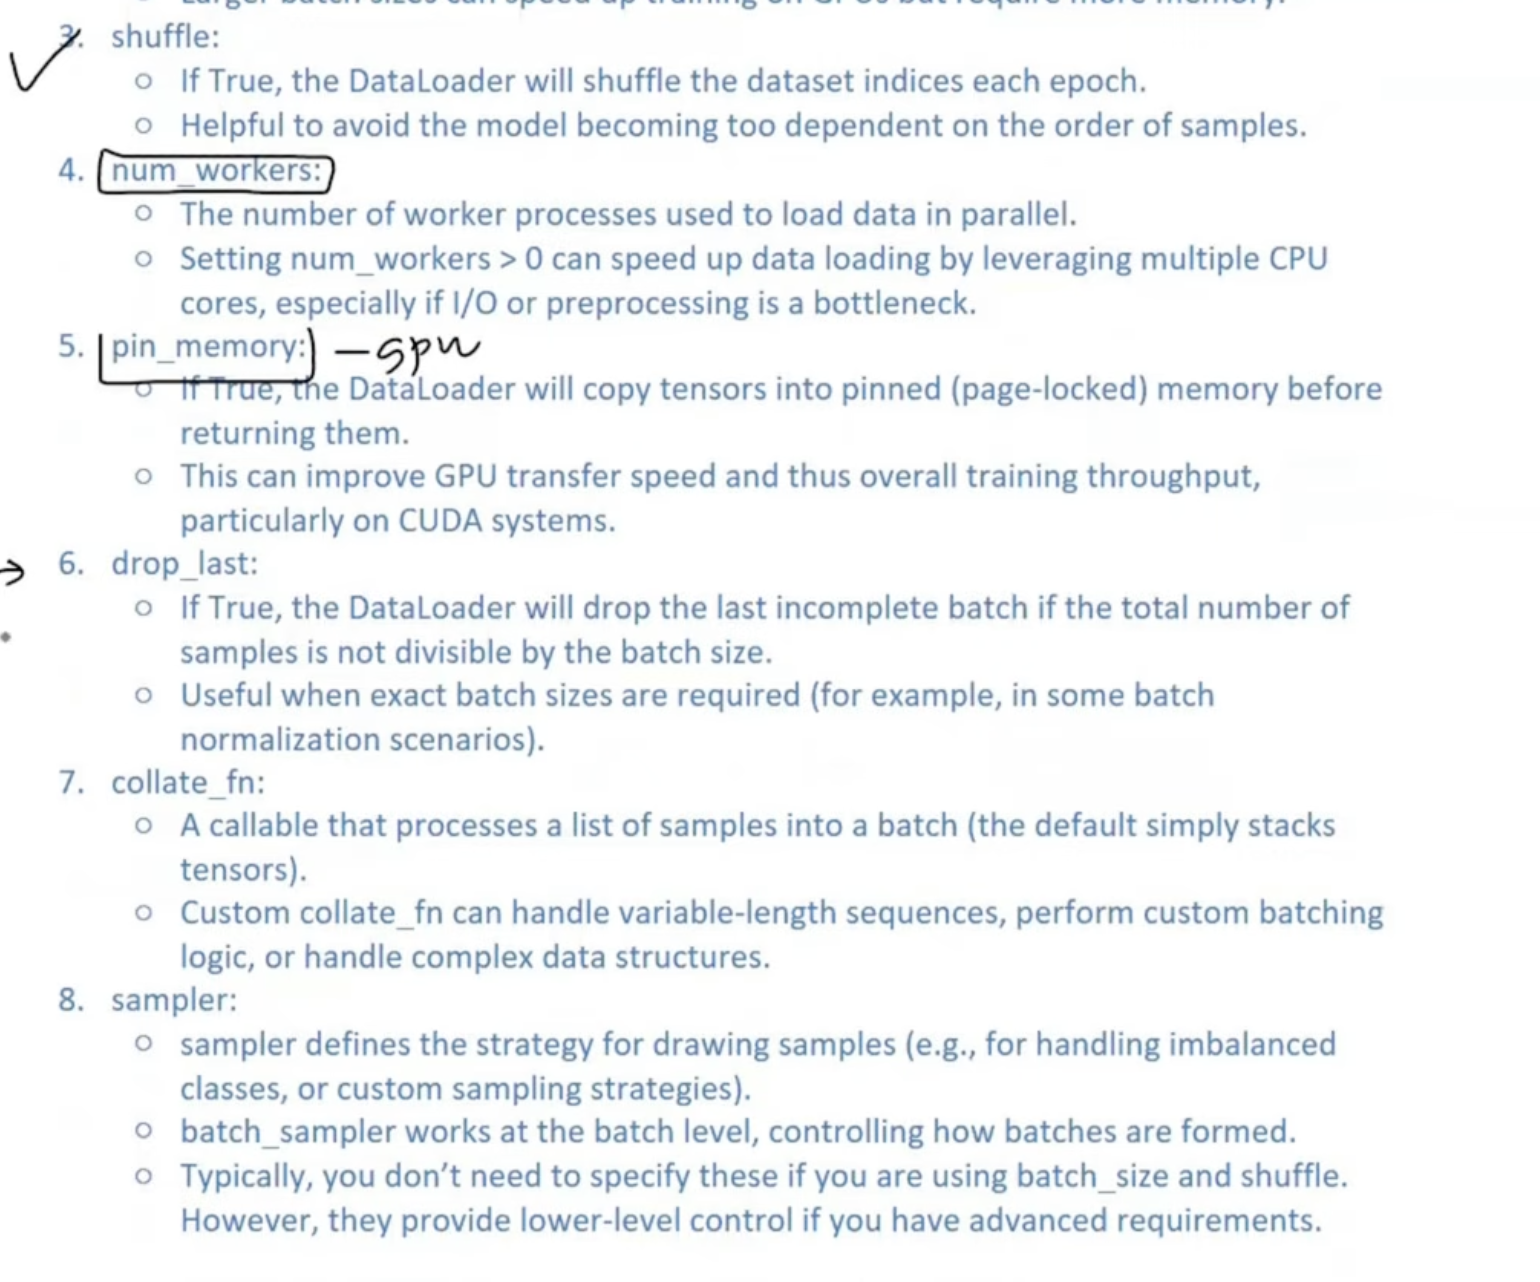